# 01 - Ingesta y consolidación de datos THETIS-MRV

**TFM: Predicción de emisiones de CO₂ de buques**

Fuente: [EMSA THETIS-MRV, informe público de emisiones](https://mrv.emsa.europa.eu/#public/emission-report),
publicado en cumplimiento del Reglamento (UE) 2015/757 (EU MRV).

Este notebook:
1. Carga los 8 informes anuales públicos descargados en `data/raw/` (2018-2025).
2. Aplana la cabecera de 3 filas de cada fichero a nombres de columna homogéneos entre años.
3. Consolida todos los años (y las coberturas parcial/completa de 2024-2025) en un único dataset.
4. Hace una primera inspección de calidad de datos (dtypes, missings, duplicados) con las
   funciones de `src/eda_utils.py` (`analizar_variables_categoricas`, `cuentaDistintos`,
   `patron_perdidos`, etc.).
5. Guarda el resultado en `data/processed/` para su uso en el resto del TFM.

**Derechos de uso de los datos**: la publicación es obligatoria para la Comisión (art. 21.1 del
Reglamento) y la reutilización está autorizada citando la fuente; el detalle está en el apartado 2
de la memoria.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / "src"))
from ingest_mrv import YEAR_FILES, load_all_years

pd.set_option("display.max_columns", 50)
RAW_DIR = Path.cwd().parent / "data" / "raw"
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

YEAR_FILES

{2018: ('2018-v275-EU_MRV_Publication_of_information.xlsx',
  [('2018', 'Full')]),
 2019: ('2019-v228-EU_MRV_Publication_of_information.xlsx',
  [('2019', 'Full')]),
 2020: ('2020-v209-EU_MRV_Publication_of_information.xlsx',
  [('2020', 'Full')]),
 2021: ('2021-v218-EU_MRV_Publication_of_information.xlsx',
  [('2021', 'Full')]),
 2022: ('2022-v241-EU_MRV_Publication_of_information.xlsx',
  [('2022', 'Full')]),
 2023: ('2023-v91-EU_MRV_Publication_of_information.xlsx', [('2023', 'Full')]),
 2024: ('2024-v235-EU_MRV_Publication_of_information.xlsx',
  [('2024 Full ERs', 'Full'), ('2024 Partial ERs', 'Partial')]),
 2025: ('2025-v37-EU_MRV_Publication_of_information.xlsx',
  [('2025 Full ERs', 'Full'), ('2025 Partial ERs', 'Partial')])}

## 1. Carga y consolidación de los 8 años

In [2]:
datos, diccionario_variables = load_all_years(RAW_DIR)

print(f"\nDataset consolidado: {datos.shape[0]:,} filas x {datos.shape[1]} columnas".replace(",", "."))
datos.head(3)

  2018 (Full   ) <- '2018':  12260 filas, 65 columnas


  2019 (Full   ) <- '2019':  12420 filas, 65 columnas


  2020 (Full   ) <- '2020':  12117 filas, 65 columnas


  2021 (Full   ) <- '2021':  12484 filas, 65 columnas


  2022 (Full   ) <- '2022':  13474 filas, 65 columnas


...

  2024 (Partial) <- '2024 Partial ERs':   1027 filas, 116 columnas


  2025 (Full   ) <- '2025 Full ERs':  16960 filas, 116 columnas


  2025 (Partial) <- '2025 Partial ERs':   1512 filas, 116 columnas



Dataset consolidado: 109.240 filas x 134 columnas


,reporting_year,report_coverage,source_file,ship_imo_number,ship_name,ship_type,reporting_period,technical_efficiency,port_of_registry,home_port,ice_class,doc_issue_date,doc_expiry_date,verifier_number,verifier_name,verifier_nab,verifier_address,verifier_city,verifier_accreditation_number,verifier_country,monitoring_methods_a,monitoring_methods_b,monitoring_methods_c,monitoring_methods_d,monitoring_methods_d_2,...,fuel_consumption_per_transport_work_volume_g_m3_n_miles,fuel_consumption_per_transport_work_dwt_g_dwt_carried_n_miles,fuel_consumption_per_transport_work_pax_g_pax_n_miles,fuel_consumption_per_transport_work_freight_g_m_tonnes_n_miles,fuel_consumption_per_time_spent_at_sea_m_tonnes_hour,co2_emissions_per_distance_kg_co2_n_mile,co2_emissions_per_transport_work_mass_g_co2_m_tonnes_n_miles,co2_emissions_per_transport_work_volume_g_co2_m3_n_miles,co2_emissions_per_transport_work_dwt_g_co2_dwt_carried_n_miles,co2_emissions_per_transport_work_pax_g_co2_pax_n_miles,co2_emissions_per_transport_work_freight_g_co2_m_tonnes_n_miles,co2_emissions_per_time_spent_at_sea_m_tonnes_co2_hour,co2eq_emissions_per_distance_kg_co2eq_n_mile,co2eq_emissions_per_distance_on_laden_voyages_kg_co2eq_n_mile,co2eq_emissions_per_transport_work_mass_g_co2eq_m_tonnes_n_miles,co2eq_emissions_per_transport_work_mass_on_laden_voyages_g_co2eq_m_tonnes_n_miles,co2eq_emissions_per_transport_work_volume_g_co2eq_m3_n_miles,co2eq_emissions_per_transport_work_volume_on_laden_voyages_g_co2eq_m3_n_miles,co2eq_emissions_per_transport_work_dwt_g_co2eq_dwt_carried_n_miles,co2eq_emissions_per_transport_work_dwt_on_laden_voyages_g_co2eq_dwt_carried_n_miles,co2eq_emissions_per_transport_work_pax_g_co2eq_pax_n_miles,co2eq_emissions_per_transport_work_pax_on_laden_voyages_g_co2eq_pax_n_miles,co2eq_emissions_per_transport_work_freight_g_co2eq_m_tonnes_n_miles,co2eq_emissions_per_transport_work_freight_on_laden_voyages_g_co2eq_m_tonnes_n_miles,co2eq_emissions_per_time_spent_at_sea_m_tonnes_co2eq_m_tonnes_n_miles
0,2018,Full,2018-v275-EU_MRV_Publication_of_information.xlsx,5383304,ASTORIA,Passenger ship,2018,Not Applicable,NaN,NaN,NaN,05/02/2019,30/06/2020,NaN,ICS Verification Services Single Member P.C.,Hellenic Accredidation System,"16, Efplias Str.\n185 37 Piraeus, Greece",Piraeus,1101-3,Greece,Yes,NaN,NaN,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,Full,2018-v275-EU_MRV_Publication_of_information.xlsx,6417097,MARCO POLO,Passenger ship,2018,Not Applicable,NaN,NaN,IC,05/02/2019,30/06/2020,NaN,ICS Verification Services Single Member P.C.,Hellenic Accredidation System,"16, Efplias Str.\n185 37 Piraeus, Greece",Piraeus,1101-3,Greece,Yes,NaN,NaN,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,Full,2018-v275-EU_MRV_Publication_of_information.xlsx,6511128,RED STAR 1,Ro-pax ship,2018,EIV (45.57 gCO₂/t·nm),NaN,NaN,NaN,30/04/2019,30/06/2020,NaN,VERIFAVIA (UK) LTD,UKAS,20-22 Wenlock Road,London,4599,United Kingdom,Yes,NaN,NaN,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


El diccionario de variables recoge, para cada nombre técnico de columna, la etiqueta original
tal y como aparece en el portal (grupo + nombre de la variable). Se guarda como anexo de
referencia del TFM.

In [3]:
diccionario_variables.to_csv(PROCESSED_DIR / "diccionario_variables.csv", index=False)
diccionario_variables.head(15)

,columna,etiqueta_original_portal
0,additional_information_to_facilitate_the_under...,Additional information to facilitate the under...
1,annual_average_co2_emissions_per_distance_kg_c...,Annual average CO₂ emissions per distance [kg ...
2,annual_average_co2_emissions_per_transport_wor...,Annual average CO₂ emissions per transport wor...
3,annual_average_co2_emissions_per_transport_wor...,Annual average CO₂ emissions per transport wor...
4,annual_average_co2_emissions_per_transport_wor...,Annual average CO₂ emissions per transport wor...
5,annual_average_co2_emissions_per_transport_wor...,Annual average CO₂ emissions per transport wor...
6,annual_average_co2_emissions_per_transport_wor...,Annual average CO₂ emissions per transport wor...
7,annual_average_fuel_consumption_per_distance_k...,Annual average Fuel consumption per distance [...
8,annual_average_fuel_consumption_per_transport_...,Annual average Fuel consumption per transport ...
9,annual_average_fuel_consumption_per_transport_...,Annual average Fuel consumption per transport ...


## 2. Comprobación de la carga: filas por año y cobertura

In [4]:
resumen_anual = (
    datos.groupby(["reporting_year", "report_coverage"], observed=True)
    .size()
    .rename("n_filas")
    .reset_index()
)
resumen_anual

,reporting_year,report_coverage,n_filas
0,2018,Full,12260
1,2019,Full,12420
2,2020,Full,12117
3,2021,Full,12484
4,2022,Full,13474
5,2023,Full,12828
6,2024,Full,14158
7,2024,Partial,1027
8,2025,Full,16960
9,2025,Partial,1512


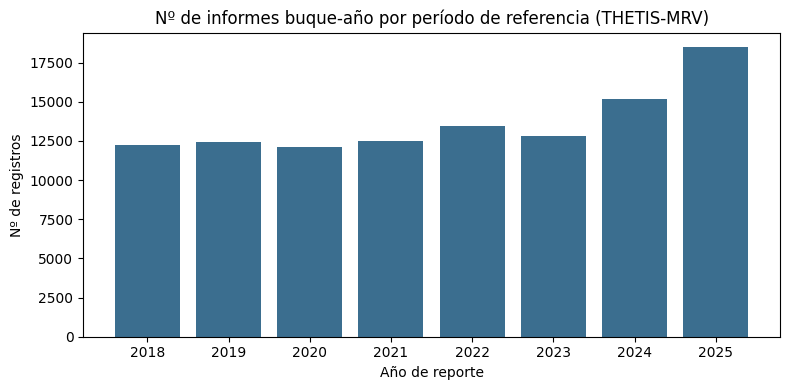

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
totales_por_anio = datos.groupby("reporting_year").size()
ax.bar(totales_por_anio.index.astype(str), totales_por_anio.values, color="#3B6E8F")
ax.set_title("Nº de informes buque-año por período de referencia (THETIS-MRV)")
ax.set_xlabel("Año de reporte")
ax.set_ylabel("Nº de registros")
plt.tight_layout()
plt.savefig(PROCESSED_DIR.parent.parent / "reports" / "01_registros_por_anio.png", dpi=120)
plt.show()

## 3. Tipos de variable

Se separan las variables numéricas de las categóricas y se revisa que el tipo asignado por pandas tenga sentido (identificadores como `ship_imo_number`
se mantienen como texto, no como número).

In [6]:
variables = list(datos.columns)
numericas = datos.select_dtypes(include=["int", "int32", "int64", "float", "float32", "float64"]).columns.tolist()
categoricas = [v for v in variables if v not in numericas]

print(f"Variables numéricas: {len(numericas)}")
print(f"Variables categóricas/texto: {len(categoricas)}")
datos.dtypes.value_counts()

Variables numéricas: 98
Variables categóricas/texto: 36


float64    97
str        34
object      2
int64       1
Name: count, dtype: int64

## 4. Valores perdidos (missings)

In [7]:
prop_missings_var = datos[variables].isna().mean().sort_values(ascending=False)
prop_missings_var.head(20).to_frame("proporcion_missing")

,proporcion_missing
monitoring_methods_d_2,1.000000
fuel_consumptions_assigned_to_cargo_heating_m_tonnes,0.999963
monitoring_methods_d,0.999945
average_density_of_the_cargo_transported_m_tonnes_m3,0.999945
co2eq_emissions_per_transport_work_pax_on_laden_voyages_g_co2eq_pax_n_miles,0.999762
fuel_consumption_per_transport_work_pax_on_laden_voyages_g_pax_n_miles,0.999661
co2_emissions_per_transport_work_pax_on_laden_voyages_g_co2_pax_n_miles,0.999423
additional_information_to_facilitate_the_understanding_of_the_reported_average_operational_energy_efficiency_indicators,0.999021
co2eq_emissions_per_transport_work_volume_on_laden_voyages_g_co2eq_m3_n_miles,0.998490
fuel_consumption_per_transport_work_volume_on_laden_voyages_g_m3_n_miles,0.996878


In [8]:
# Variables clave para el TFM: no deberían tener apenas missings en los informes completos (Full)
variables_clave = [
    "ship_imo_number", "ship_type", "reporting_year", "total_co2_emissions_m_tonnes",
    "total_fuel_consumption_m_tonnes", "total_time_spent_at_sea_hours",
]
datos.loc[datos.report_coverage == "Full", variables_clave].isna().mean().to_frame("proporcion_missing_en_full")

,proporcion_missing_en_full
ship_imo_number,0.000000
ship_type,0.000000
reporting_year,0.000000
total_co2_emissions_m_tonnes,0.000000
total_fuel_consumption_m_tonnes,0.000000
total_time_spent_at_sea_hours,0.768699


## 5. Duplicados y consistencia del identificador de buque

A primera vista, agrupar solo por (año, cobertura, buque) da la impresión de que hay filas
duplicadas: 55 filas comparten esa combinación. **No lo son.** Al mirar el detalle, cada pareja
corresponde a un buque que cambió de compañía naviera (y a veces de nombre) a mitad de año, y que
por tanto tiene más de un informe **parcial** (Art. 11(2) del Reglamento), cada uno con su propio
rango de fechas y su propia compañía. Al añadir esas dos columnas a la clave, los duplicados
desaparecen del todo.

In [9]:
# Comprobación "ingenua": parece haber 55 duplicados...
clave_ingenua = ["reporting_year", "report_coverage", "ship_imo_number"]
print(f"'Duplicados' con clave (año, cobertura, IMO): {datos.duplicated(subset=clave_ingenua).sum()}")

# ...pero al añadir el período exacto y la compañía, no lo son: son informes PARCIALES distintos
# del mismo buque (cambio de armador a mitad de año).
clave_completa = clave_ingenua + ["reporting_period", "company_name"]
print(f"Duplicados con clave (año, cobertura, IMO, período, compañía): {datos.duplicated(subset=clave_completa).sum()}")
print(f"Filas 100% idénticas en todas las columnas: {datos.duplicated(keep=False).sum()}")

# Ejemplo ilustrativo
ejemplo_imo = datos[datos.duplicated(subset=clave_ingenua, keep=False)]["ship_imo_number"].iloc[0]
datos[
    (datos.ship_imo_number == ejemplo_imo) & (datos.reporting_year == datos.loc[datos.ship_imo_number == ejemplo_imo, "reporting_year"].iloc[0])
][["reporting_year", "report_coverage", "ship_name", "company_name", "reporting_period", "total_co2_emissions_m_tonnes"]]

'Duplicados' con clave (año, cobertura, IMO): 55
Duplicados con clave (año, cobertura, IMO, período, compañía): 0


Filas 100% idénticas en todas las columnas: 0


,reporting_year,report_coverage,ship_name,company_name,reporting_period,total_co2_emissions_m_tonnes
804,2018,Full,VIKING PRINCESS,NaN,2018,686.3995


## 6. Informes 'Full' vs 'Partial': cuidado con contar la misma emisión dos veces

Es la observación más importante de esta primera revisión y condiciona cómo se debe construir
el dataset de modelización más adelante.

Para 2024 y 2025 el portal separa los informes en dos hojas: **Full ERs** (un informe por buque
que cubre el año completo) y **Partial ERs** (informes por tramos, cuando el buque cambió de
compañía a mitad de año). El problema es que **un mismo buque puede aparecer en ambas hojas el
mismo año**, y el informe `Full` no es un dato independiente de los `Partial`: es, o bien el total
del año agregado, o bien se solapa parcialmente con uno de los tramos.

Tratar cada fila como una observación independiente (por ejemplo, para entrenar un modelo
"una fila = un buque-año") supondría **contar parte de las emisiones del mismo buque más de
una vez**.

In [10]:
# Se comprueba en todos los años que tienen informes Partial (2024 y 2025), no solo en uno.
anios_con_partial = sorted(datos.loc[datos.report_coverage == "Partial", "reporting_year"].unique())

for anio in anios_con_partial:
    full_anio = datos[(datos.reporting_year == anio) & (datos.report_coverage == "Full")]
    partial_anio = datos[(datos.reporting_year == anio) & (datos.report_coverage == "Partial")]
    buques_solapados = sorted(set(full_anio.ship_imo_number) & set(partial_anio.ship_imo_number))

    print(f"--- {anio} ---")
    print(f"Buques que aparecen en Full Y en Partial: {len(buques_solapados)} de {len(full_anio)} buques Full")

    # Para cada buque solapado, se compara el CO2 del informe Full con la suma de sus informes Partial
    comparacion = []
    for imo in buques_solapados:
        co2_full = full_anio.loc[full_anio.ship_imo_number == imo, "total_co2_emissions_m_tonnes"].sum()
        co2_partial = partial_anio.loc[partial_anio.ship_imo_number == imo, "total_co2_emissions_m_tonnes"].sum()
        if co2_full:
            comparacion.append(co2_partial / co2_full)

    comparacion = pd.Series(comparacion)
    print("Distribución de (suma CO2 Partial) / (CO2 Full) para los buques solapados:")
    print(comparacion.describe(percentiles=[.1, .25, .5, .75, .9]))
    print()


--- 2024 ---
Buques que aparecen en Full Y en Partial: 726 de 14158 buques Full


Distribución de (suma CO2 Partial) / (CO2 Full) para los buques solapados:
count    718.000000
mean       0.665323
std        0.333670
min        0.000000
10%        0.119421
25%        0.406191
50%        0.769525
75%        0.999998
90%        1.000000
max        1.000010
dtype: float64

--- 2025 ---
Buques que aparecen en Full Y en Partial: 1006 de 16960 buques Full


Distribución de (suma CO2 Partial) / (CO2 Full) para los buques solapados:
count    921.000000
mean       0.632900
std        0.356298
min        0.000000
10%        0.007780
25%        0.343076
50%        0.707516
75%        1.000000
90%        1.000000
max        1.000000
dtype: float64



El mismo patrón se confirma en los dos años que tienen informes `Partial` (2024 y 2025, celda anterior) -- no es una particularidad de 2024. La mayoría de los casos tiene un ratio claramente por debajo de 1: el informe `Partial` recoge
solo una parte de lo que ya está contabilizado en el `Full` de ese mismo buque. Es decir, **`Full`
es el dato autoritativo de "emisiones del buque en el año"**, y `Partial` es un desglose
complementario por operador, útil para otro tipo de análisis (por ejemplo, atribuir emisiones
a la compañía responsable de cada tramo) pero no debe sumarse ni tratarse como una fila
independiente en el dataset principal de modelización.

**Decisión metodológica para el resto del TFM:** el dataset de modelización (predicción de
emisiones por buque-año) se construirá filtrando `report_coverage == 'Full'`. Las filas `Partial`
se conservan en `mrv_consolidado.parquet` por transparencia y como posible análisis complementario
(p.ej. efecto del cambio de armador), pero quedan fuera del conjunto de entrenamiento por defecto.

## 7. Aviso de calidad de datos: atípicos evidentes en el origen

Una revisión rápida de los máximos de las variables numéricas deja ver al menos un valor
imposible que se trata en el notebook de EDA (tratamiento de atípicos con `atipicosAmissing`): un buque no puede
pasar más horas en el mar en un año de las que tiene el año (8.784 h como máximo).

In [11]:
horas_por_anio_max = 366 * 24  # cota física: ningún buque puede navegar más horas que las que tiene el año
imposibles = datos[datos["total_time_spent_at_sea_hours"] > horas_por_anio_max]
print(f"Filas con más horas en el mar de las físicamente posibles en un año: {len(imposibles)}")
imposibles[["reporting_year", "ship_imo_number", "ship_name", "total_time_spent_at_sea_hours"]]

Filas con más horas en el mar de las físicamente posibles en un año: 19


,reporting_year,ship_imo_number,ship_name,total_time_spent_at_sea_hours
653,2018,9109768,TARIQ IBN ZIYAD,1.112447e+04
1397,2018,9203605,AYSHE,2.760230e+05
4111,2018,9334325,SARACENA,1.430015e+04
6385,2018,9442108,SIYA,1.131274e+04
7167,2018,9480655,BLACK SHARK,9.692020e+03
8417,2018,9573816,TRAMONTANA,1.008217e+04
9339,2018,9626948,PACIFIC BLESS,8.817360e+03
9689,2018,9655224,ALKYON,2.769800e+04
11804,2018,9776767,TIGANI,9.294000e+03
11887,2018,9782302,CAPE TAWEELAH,4.183996e+04


Son valores claramente erróneos en origen (varios órdenes de magnitud por encima de lo físicamente
posible, no un simple redondeo). Se dejan documentados aquí y se tratarán como atípicos/missing en
el notebook 02 —convirtiendo solo esa celda en missing, no descartando la fila entera, salvo que
el resto de variables de esa fila también resulten inconsistentes.

## 7b. Validación física: ¿el CO₂ reportado es coherente con el combustible consumido?

Una comprobación de sanidad independiente de las anteriores: la propia normativa MRV define el
CO₂ emitido como el consumo de combustible multiplicado por un factor de emisión fijo según el
tipo de combustible (~3,114 t CO₂/t combustible para fuel-oil pesado, ~3,206 para diésel/gasóleo
marino, algo menor para GNL). Si los datos son consistentes, ese ratio debería agruparse muy cerca
de esos valores en **todos los años**, lo que sirve como validación cruzada de que no ha cambiado
la definición de las variables ni las unidades entre 2018 y 2025.

In [12]:
full = datos[datos.report_coverage == "Full"].copy()
full["ratio_co2_fuel"] = full["total_co2_emissions_m_tonnes"] / full["total_fuel_consumption_m_tonnes"]

print("Ratio CO2/combustible por año (mediana) — debería rondar 3,11-3,21 todos los años:")
print(full.groupby("reporting_year")["ratio_co2_fuel"].median())

# Filas fuera del rango físicamente plausible (con margen para GNL y para mezclas de combustible)
atipicos_ratio = full[
    (full.total_fuel_consumption_m_tonnes > 0)
    & ((full.ratio_co2_fuel < 2.5) | (full.ratio_co2_fuel > 3.3))
]
print(f"\nFilas fuera de [2,5, 3,3] t CO2/t combustible: {len(atipicos_ratio)} de {full.total_fuel_consumption_m_tonnes.gt(0).sum()} "
      f"({len(atipicos_ratio) / full.total_fuel_consumption_m_tonnes.gt(0).sum():.2%})")

inconsistentes = full[(full.total_fuel_consumption_m_tonnes > 0) & (full.total_co2_emissions_m_tonnes == 0)]
print(f"Filas con combustible > 0 pero CO2 = 0 (inconsistencia clara): {len(inconsistentes)}")

Ratio CO2/combustible por año (mediana) — debería rondar 3,11-3,21 todos los años:
reporting_year
2018    3.130179
2019    3.131407
2020    3.148935
2021    3.146196
2022    3.142398
2023    3.137999
2024    3.132636
2025    3.140904
Name: ratio_co2_fuel, dtype: float64

Filas fuera de [2,5, 3,3] t CO2/t combustible: 180 de 101063 (0.18%)
Filas con combustible > 0 pero CO2 = 0 (inconsistencia clara): 4


La mediana del ratio se mantiene estable entre 3,11 y 3,21 en los 8 años — confirma que las
variables `total_co2_emissions_m_tonnes` y `total_fuel_consumption_m_tonnes` significan lo mismo
y están en las mismas unidades en todo el histórico, algo que no se puede dar por supuesto sin
comprobarlo cuando se combinan 8 ficheros independientes publicados a lo largo de varios años.

El pequeño porcentaje de filas fuera de rango (bajo, pero no cero) es un tercer grupo de atípicos
—además de las horas en el mar imposibles (Sección 7) y los duplicados aparentes ya aclarados
(Sección 5)— que se trata en el notebook 02. Todas estas observaciones son coherentes con lo
esperado en un dataset administrativo de auto-declaración a esta escala (~110k registros): ruido
de captura puntual, no un problema sistemático de la fuente.

## 8. Guardado del dataset consolidado

Se guarda en formato Parquet (eficiente para ~110k filas x 130+ columnas) en `data/processed/`.
Este será el punto de partida del EDA estadístico (notebook 02) y de la preparación de variables
para modelización (notebook 03).

In [13]:
out_path = PROCESSED_DIR / "mrv_consolidado.parquet"
datos.to_parquet(out_path, index=False)
print(f"Guardado: {out_path.relative_to(Path.cwd().parent)}  ({out_path.stat().st_size / 1e6:.1f} MB)")

Guardado: data/processed/mrv_consolidado.parquet  (15.0 MB)


## 9. Conceptos partidos por cambio de rótulo entre años

En el EDA (notebook 02) se observa que, sin este tratamiento, `time_spent_at_sea_hours` tenía un
77% de missings en los informes `Full` — una proporción demasiado alta para una variable
obligatoria del reglamento. La causa no era un problema de los datos, sino del aplanado de
cabecera: el portal ha usado un rótulo de grupo distinto para la misma variable "Time spent at
sea [hours]" según el año (`total_time_spent_at_sea_hours` en 2018-2019 vs
`time_spent_at_sea_hours` en 2020-2025), así que la regla de nombrado (que sí es consistente
*dentro* de un mismo año) genera dos columnas que nunca coexisten para el mismo buque-año.

Se comprobó que, en los años en los que coexisten ambas columnas del mismo concepto
(`time_spent_at_sea_hours` y su variante `total_time_spent_at_sea_hours`, con dato simultáneo en
24.680 filas), sus valores son idénticos en el 100% de los casos — confirma que es la misma
variable duplicada, no dos variables distintas. `src/ingest_mrv.py` completa cada columna
canónica con su variante cuando falta (`_coalesce_split_concepts`), y el diccionario de variables
anota qué columnas quedan redundantes. Los datos de este notebook ya incorporan esa fusión.

In [14]:
print("Missings en time_spent_at_sea_hours (Full) antes del arreglo: 77%")
faltan_ahora = datos.loc[datos.report_coverage == "Full", "time_spent_at_sea_hours"].isna().mean()
print(f"Missings en time_spent_at_sea_hours (Full) después del arreglo: {faltan_ahora:.1%}")

Missings en time_spent_at_sea_hours (Full) antes del arreglo: 77%
Missings en time_spent_at_sea_hours (Full) después del arreglo: 0.0%


## 10. Dos parejas más del mismo problema, encontradas con un barrido sistemático

Para no depender de encontrar el resto de casos "a ojo" durante el EDA, se hace un barrido
sistemático de las 134 columnas buscando pares con
un único token de diferencia en el nombre (p.ej. `total_x` / `x`) y cobertura de datos casi
perfectamente complementaria (nunca tienen dato ambas a la vez) — la misma firma del caso anterior.
Aparecen dos parejas más, ambas del bloque de navegación en hielo, con el mismo patrón de
cambio de rótulo entre 2018-2023 y 2024-2025:

| Concepto | Nombre 2018-2023 | Nombre 2024-2025 |
|---|---|---|
| Tiempo en mar navegando en hielo | `total_time_spent_at_sea_through_ice_hours` | `time_spent_at_sea_through_ice_hours` |
| Distancia navegada en hielo | `through_ice_n_miles` | `distance_through_ice_n_miles` |

Verificado igual que en la sección 9: solape 0 filas entre cada pareja (nunca coexisten) y misma
etiqueta de negocio en el portal salvo el rótulo de grupo. Ninguna de las dos variables se usa en
el EDA núcleo del notebook 02 (son específicas de buques que navegan en hielo, una minoría de la
flota), así que no cambian ninguna conclusión — pero sí afectarían a cualquier análisis de `ship_type`/`ice_class` que quisiera usar estas variables, con la
misma pérdida silenciosa de ~46% del dato disponible que tendría `time_spent_at_sea_hours`.

**Tratamiento en `src/ingest_mrv.py`:**
1. Las dos parejas están en `_CONCEPTOS_DIVIDIDOS` y se fusionan igual que las anteriores.
2. Comprobación defensiva: si dos columnas de `_CONCEPTOS_DIVIDIDOS` tuvieran dato en la misma
   fila pero con valores distintos, la ingesta lanza un error en vez de fusionar a ciegas.
3. El barrido sistemático se ejecuta como aviso automático (`_detectar_conceptos_partidos_sin_resolver`):
   si en una futura actualización de datos (p.ej. al añadir el año 2026) aparece un nuevo par con
   esta misma firma y no está en `_CONCEPTOS_DIVIDIDOS`, la ingesta lo imprime como aviso.

In [15]:
for canonica, variante in [
    ("time_spent_at_sea_through_ice_hours", "total_time_spent_at_sea_through_ice_hours"),
    ("distance_through_ice_n_miles", "through_ice_n_miles"),
]:
    print(f"{canonica}: {datos[canonica].isna().mean():.1%} missing tras el arreglo "
          f"(antes, cada columna por separado: ~92-96% missing)")

time_spent_at_sea_through_ice_hours: 91.9% missing tras el arreglo (antes, cada columna por separado: ~92-96% missing)
distance_through_ice_n_miles: 91.9% missing tras el arreglo (antes, cada columna por separado: ~92-96% missing)


## Siguiente paso

- Notebook 02: análisis exploratorio estadístico (distribuciones, atípicos, correlaciones con
  las emisiones de CO₂), con el esquema de depuración atípicos → missings → imputación. Partirá de `mrv_consolidado.parquet` filtrado a
  `report_coverage == 'Full'` (ver Sección 6) y tratará como missing las horas en mar
  físicamente imposibles (ver Sección 7).